# Generalization Experiment: Downstream Classification Evaluation

This notebook evaluates only the **generalization experiment**.

It compares the selected feature sets by their performance on the downstream **20-class MNIST + Fashion-MNIST classification task**.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

RESULT_PATH = '../results_generalization/raw_generalization_results.csv'

## 1. Load results

,experiment,feature_source,seed,k,indices,accuracy,balanced_accuracy,macro_f1
0,generalization_mnist_fashion,unsupervised,0,50,"[659, 233, 263, 468, 599, 528, 519, 609, 541, ...",0.817036,0.816001,0.814754
1,generalization_mnist_fashion,supervised,0,50,"[477, 477, 261, 261, 261, 477, 43, 505, 477, 4...",0.382714,0.376652,0.341514
2,generalization_mnist_fashion,unsupervised,1,50,"[327, 286, 274, 296, 634, 204, 529, 471, 344, ...",0.812607,0.811311,0.809201
3,generalization_mnist_fashion,supervised,1,50,"[262, 505, 449, 238, 40, 477, 262, 505, 449, 4...",0.431357,0.426093,0.402613
4,generalization_mnist_fashion,unsupervised,2,50,"[661, 291, 410, 653, 347, 463, 431, 739, 39, 5...",0.815679,0.814440,0.813018


## 2. Keep only downstream classification metrics

In [ ]:
df = pd.read_csv(RESULT_PATH)
classification_cols = [
    'experiment',
    'feature_source',
    'seed',
    'k',
    'accuracy',
]

df_cls = df[classification_cols].copy()
df_cls

,experiment,feature_source,seed,k,accuracy
0,generalization_mnist_fashion,unsupervised,0,50,0.817036
1,generalization_mnist_fashion,supervised,0,50,0.382714
2,generalization_mnist_fashion,unsupervised,1,50,0.812607
3,generalization_mnist_fashion,supervised,1,50,0.431357
4,generalization_mnist_fashion,unsupervised,2,50,0.815679
5,generalization_mnist_fashion,supervised,2,50,0.412571
6,generalization_mnist_fashion,unsupervised,3,50,0.811500
7,generalization_mnist_fashion,supervised,3,50,0.410643
8,generalization_mnist_fashion,unsupervised,4,50,0.813321
9,generalization_mnist_fashion,supervised,4,50,0.424071


## 3. Mean ± std over seeds

In [9]:
summary = (
    df_cls
    .groupby(['feature_source', 'k'])[[
        'accuracy',
    ]]
    .agg(['mean', 'std'])
)

summary

accuracy          
                       mean       std
feature_source k                     
supervised     50  0.412271  0.018573
unsupervised   50  0.814029  0.002274

## 4. Simple side-by-side table

In [12]:
table = (
    df_cls
    .groupby('feature_source')[[
        'accuracy',
    ]]
    .mean()
    .sort_values('accuracy', ascending=False)
)

table.round(4)

,accuracy
feature_source,
unsupervised,0.8140
supervised,0.4123


## 5. Plot downstream classification accuracy

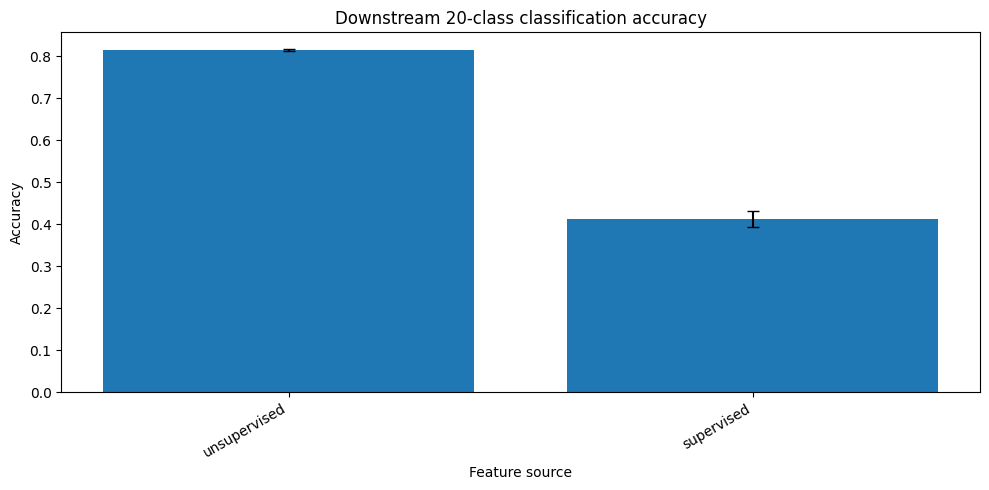

In [13]:
plot_df = (
    df_cls
    .groupby('feature_source')['accuracy']
    .agg(['mean', 'std'])
    .sort_values('mean', ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(plot_df.index, plot_df['mean'], yerr=plot_df['std'], capsize=4)
plt.ylabel('Accuracy')
plt.xlabel('Feature source')
plt.title('Downstream 20-class classification accuracy')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()